In [73]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = "Arial"

In [74]:
import random

In [75]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(6, 6))

In [76]:
adata = sc.read_10x_mtx(
    "E:/KCL/scRNAseq/scRNAseq/mouse/GSE203151/", 
    var_names = 'gene_symbols',
    cache = True
)

In [77]:
adata.obs

""
AAACCTGAGCCCAATT-1
AAACCTGAGCTAGTCT-1
AAACCTGAGCTGAAAT-1
AAACCTGAGGCAGGTT-1
AAACCTGCACGAAAGC-1
...
TTTGTCATCAAAGTAG-1
TTTGTCATCATCGCTC-1
TTTGTCATCGTGGTCG-1
TTTGTCATCTGCGGCA-1


In [78]:
np.random.seed(201)

In [79]:
adata.obs['pseudo_group'] = np.random.randint(1, 4, size=len(adata.obs))

In [80]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=['mt'], 
    percent_top = None, 
    log1p = False,
    inplace = True
)

In [81]:
adata.raw = adata

In [82]:
adata.var

,gene_ids,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
Xkr4,ENSMUSG00000051951,52,False,52,0.008143,99.201106,53.0
Sox17,ENSMUSG00000025902,137,False,137,0.058842,97.895222,383.0
Mrpl15,ENSMUSG00000033845,1521,False,1521,0.295898,76.632355,1926.0
Lypla1,ENSMUSG00000025903,1546,False,1546,0.277308,76.248272,1805.0
Tcea1,ENSMUSG00000033813,2132,False,2132,0.425872,67.245353,2772.0
...,...,...,...,...,...,...,...
Tmlhe,ENSMUSG00000079834,7,False,7,0.001075,99.892457,7.0
AC168977.1,ENSMUSG00000079808,8,False,8,0.001229,99.877093,8.0
PISD,ENSMUSG00000095041,2903,False,2903,0.654478,55.400215,4260.0
DHRSX,ENSMUSG00000063897,1406,False,1406,0.260255,78.399140,1694.0


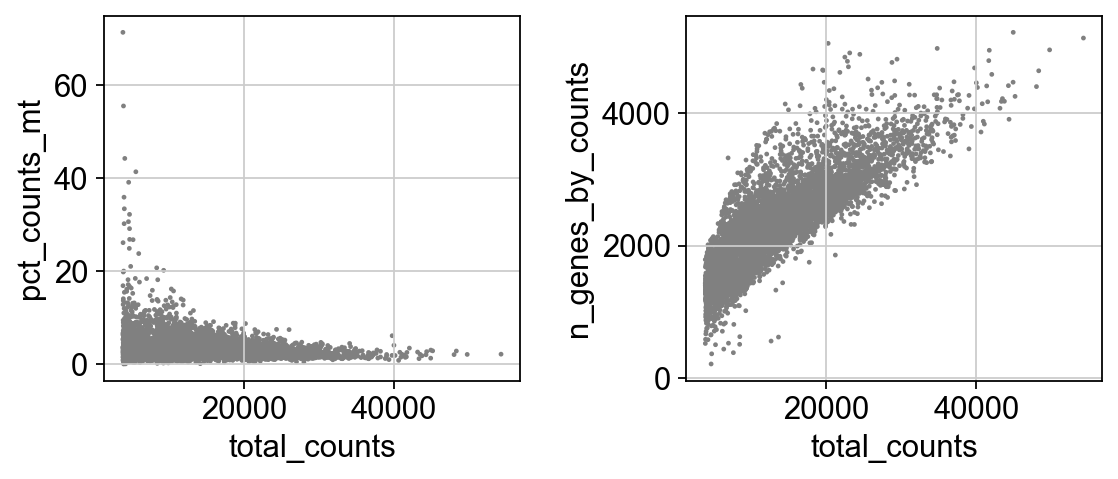

In [83]:
sc.settings.set_figure_params(dpi_save = 300)
fig, ax = plt.subplots(nrows = 1, ncols =2, figsize=(8, 3))

sc.pl.scatter(adata, x = 'total_counts', y = 'pct_counts_mt', ax = ax[0], show = False)
sc.pl.scatter(adata, x = 'total_counts', y = 'n_genes_by_counts', ax = ax[1], show = False)

plt.subplots_adjust(wspace=.4)

In [84]:
adata = adata[adata.obs.n_genes_by_counts < 4000, :]
adata = adata[adata.obs.pct_counts_mt < 10, :]

In [85]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\preprocessing\_normalization.py:206: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


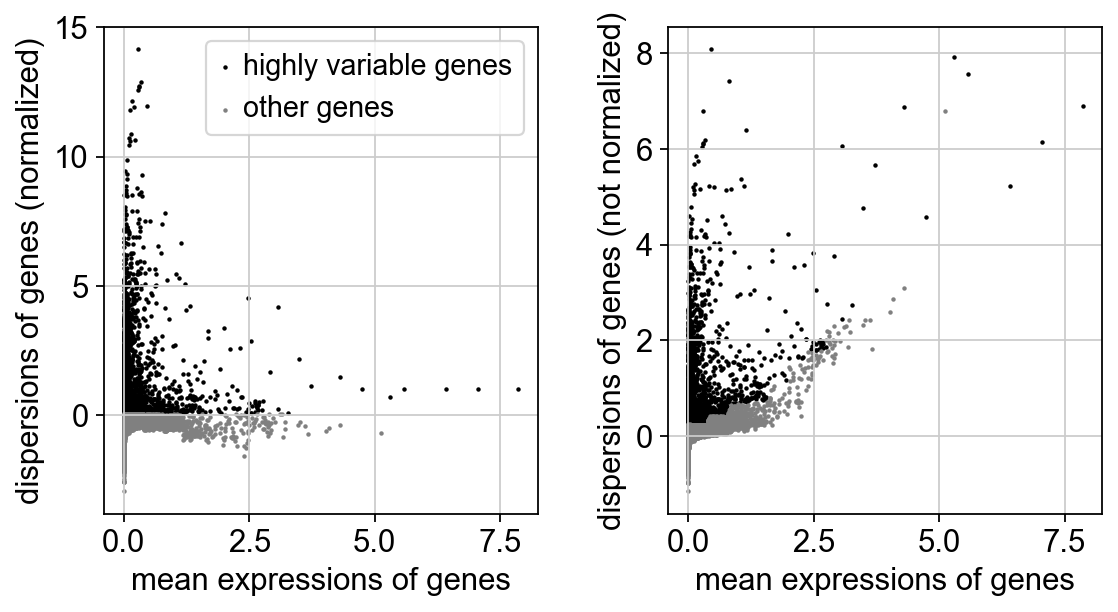

In [86]:
sc.pp.highly_variable_genes(adata, min_mean = 0.0125, max_mean=3, min_disp=0.5, n_top_genes = 4000)
sc.pl.highly_variable_genes(adata)

In [87]:
adata = adata[:, adata.var.highly_variable]

In [88]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
#不同细胞的total counts和线粒体基因比例可能不同，这种差异可能和测序深度有关，通过回归将这种差异去除掉

sc.pp.scale(adata, max_value=10)

D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\preprocessing\_simple.py:641: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


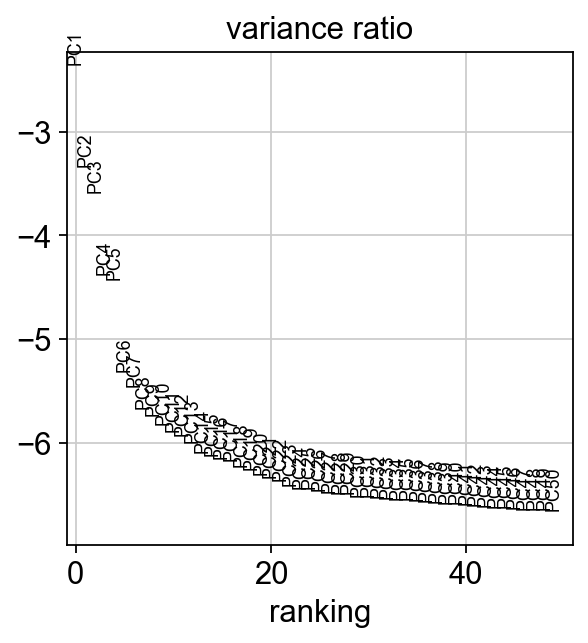

In [89]:
sc.tl.pca(adata, svd_solver = 'arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

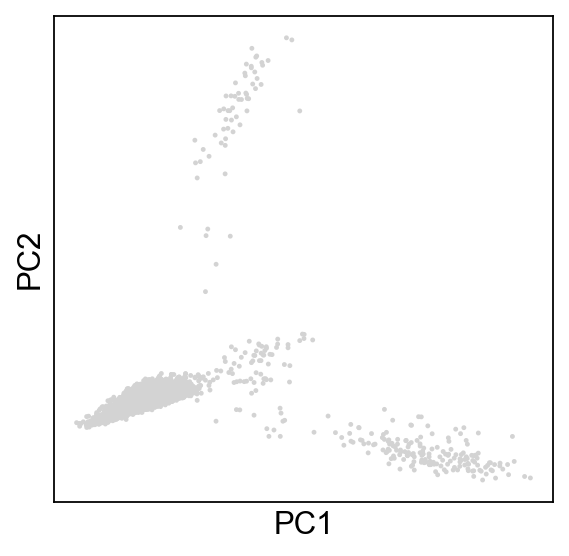

In [90]:
sc.pl.pca(adata)

In [91]:
sc.pp.neighbors(adata, n_neighbors = 10, n_pcs = 30)
sc.tl.umap(adata)

In [92]:
sc.tl.leiden(adata, resolution=0.4)

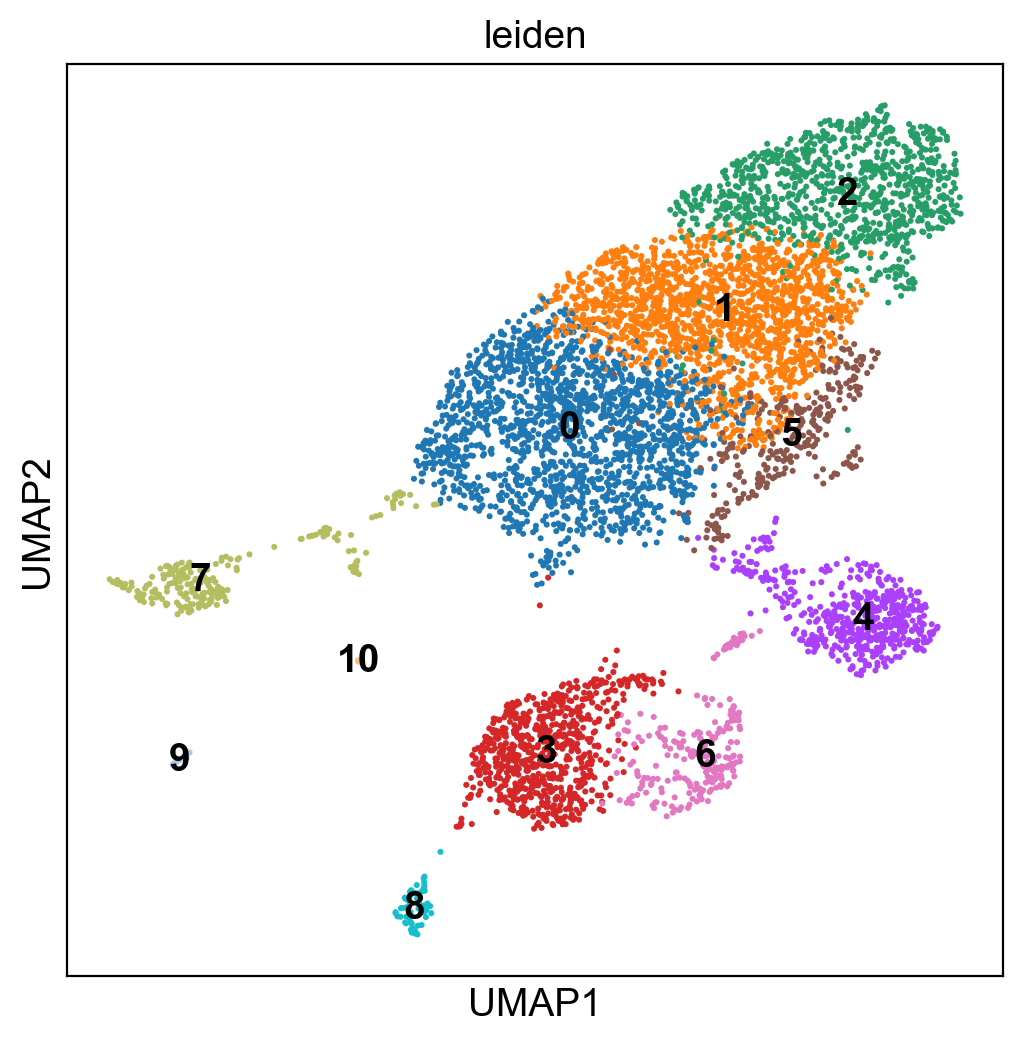

In [93]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(6, 6))
sc.pl.umap(adata, color = 'leiden', legend_loc= "on data")

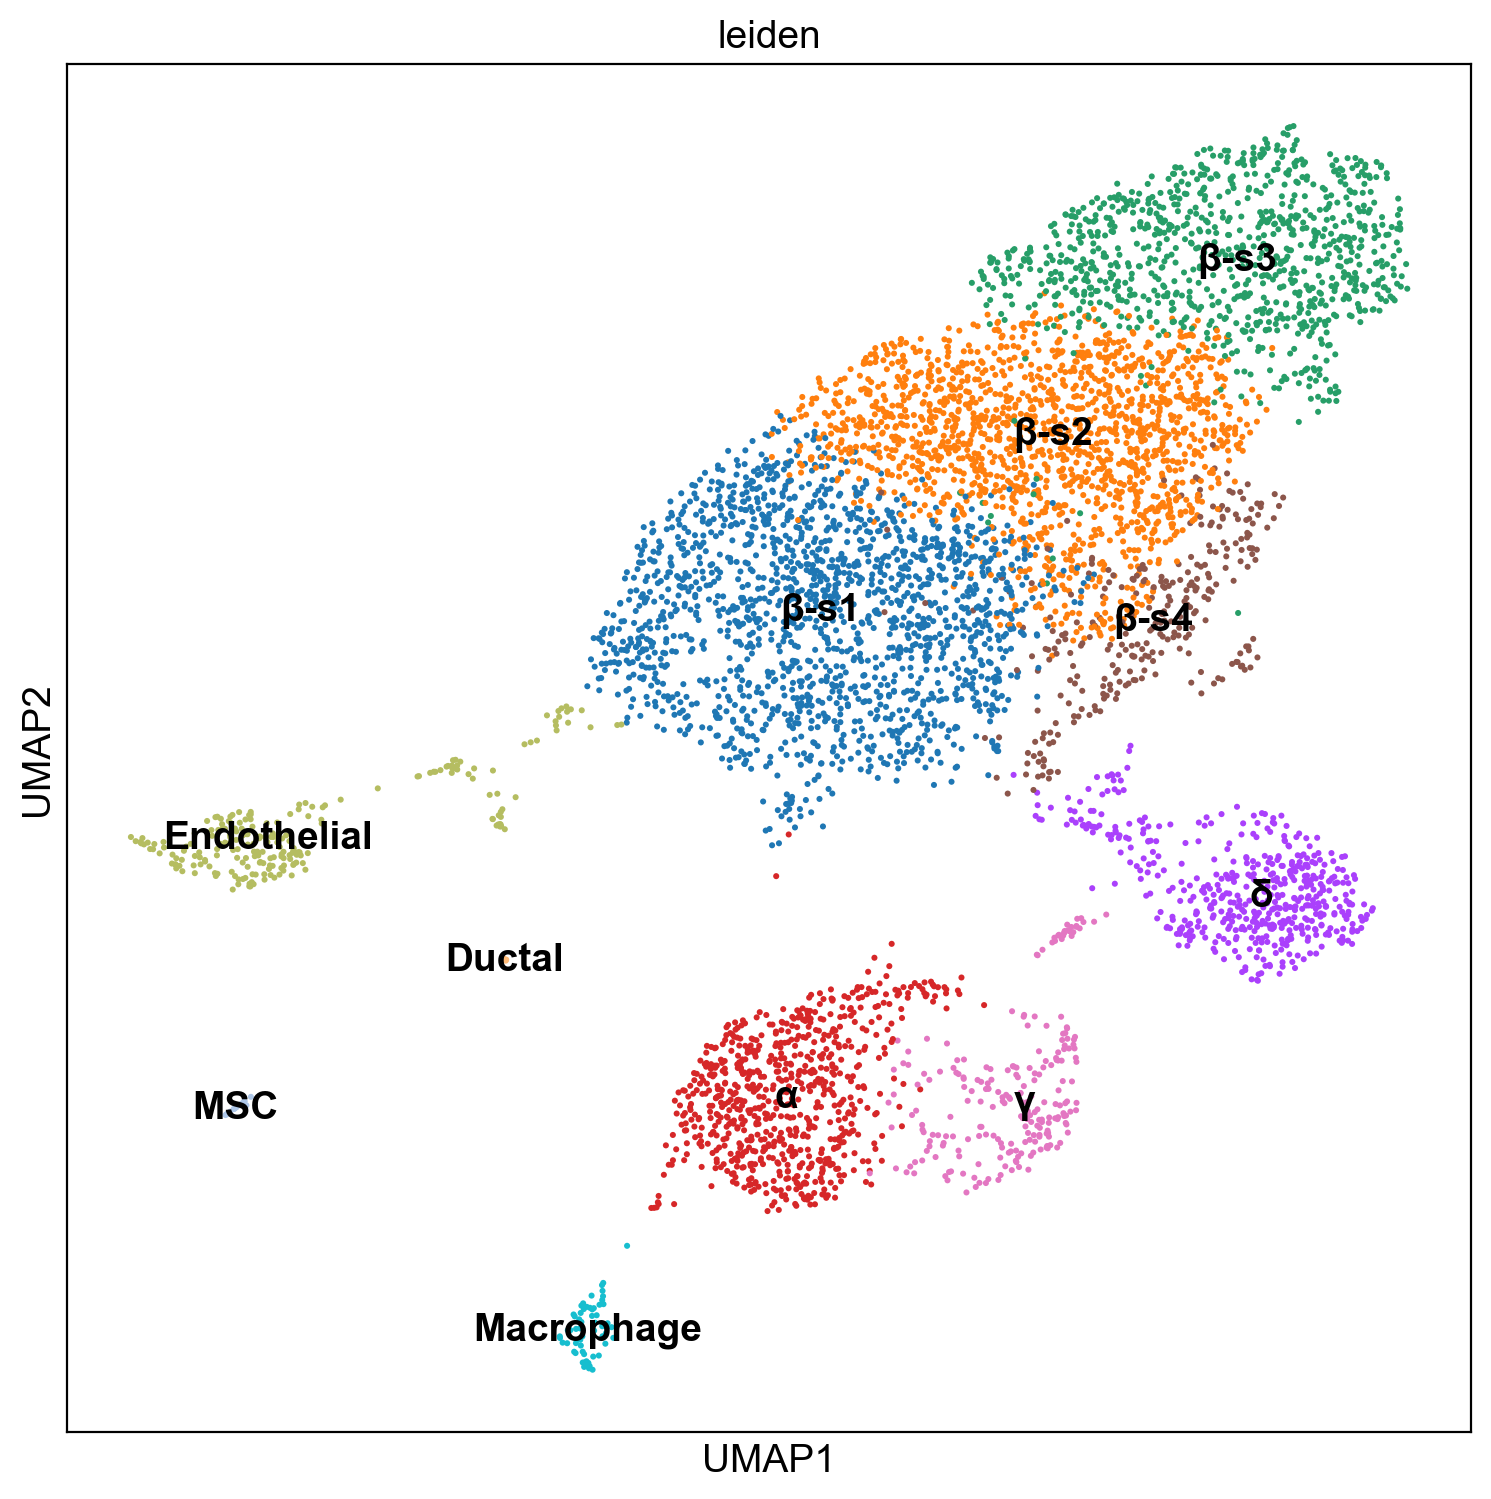

In [94]:
new_cluster_names = [
    "β-s1",
    "β-s2",
    "β-s3",
    "α",
    "δ",
    "β-s4",
    "γ",
    "Endothelial",
    "Macrophage",
    "MSC",
    "Ductal",
]

adata.rename_categories('leiden', new_cluster_names)

sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(9, 9))
sc.pl.umap(adata, color = 'leiden', legend_loc = 'on data')

In [95]:
adata.obs

,pseudo_group,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden
AAACCTGAGCCCAATT-1,1,1647,1646,10756.0,258.0,2.398661,β-s3
AAACCTGAGCTAGTCT-1,2,2915,2915,19305.0,475.0,2.460502,β-s1
AAACCTGAGCTGAAAT-1,1,3031,3031,24785.0,600.0,2.420819,γ
AAACCTGAGGCAGGTT-1,2,1890,1890,4305.0,35.0,0.813008,Endothelial
AAACCTGCACGAAAGC-1,1,1449,1449,4447.0,95.0,2.136272,α
...,...,...,...,...,...,...,...
TTTGTCATCAAAGTAG-1,3,2075,2075,9095.0,334.0,3.672348,γ
TTTGTCATCATCGCTC-1,3,2081,2081,9581.0,686.0,7.160004,β-s1
TTTGTCATCGTGGTCG-1,3,1277,1277,4768.0,213.0,4.467282,β-s3
TTTGTCATCTGCGGCA-1,2,2101,2101,11558.0,201.0,1.739055,γ


In [96]:
beta_subtypes = ["β-s1", "β-s2", "β-s3", "β-s4"]

adata.obs["leiden_new"] = adata.obs["leiden"].apply(lambda x: "β" if x in beta_subtypes else x)

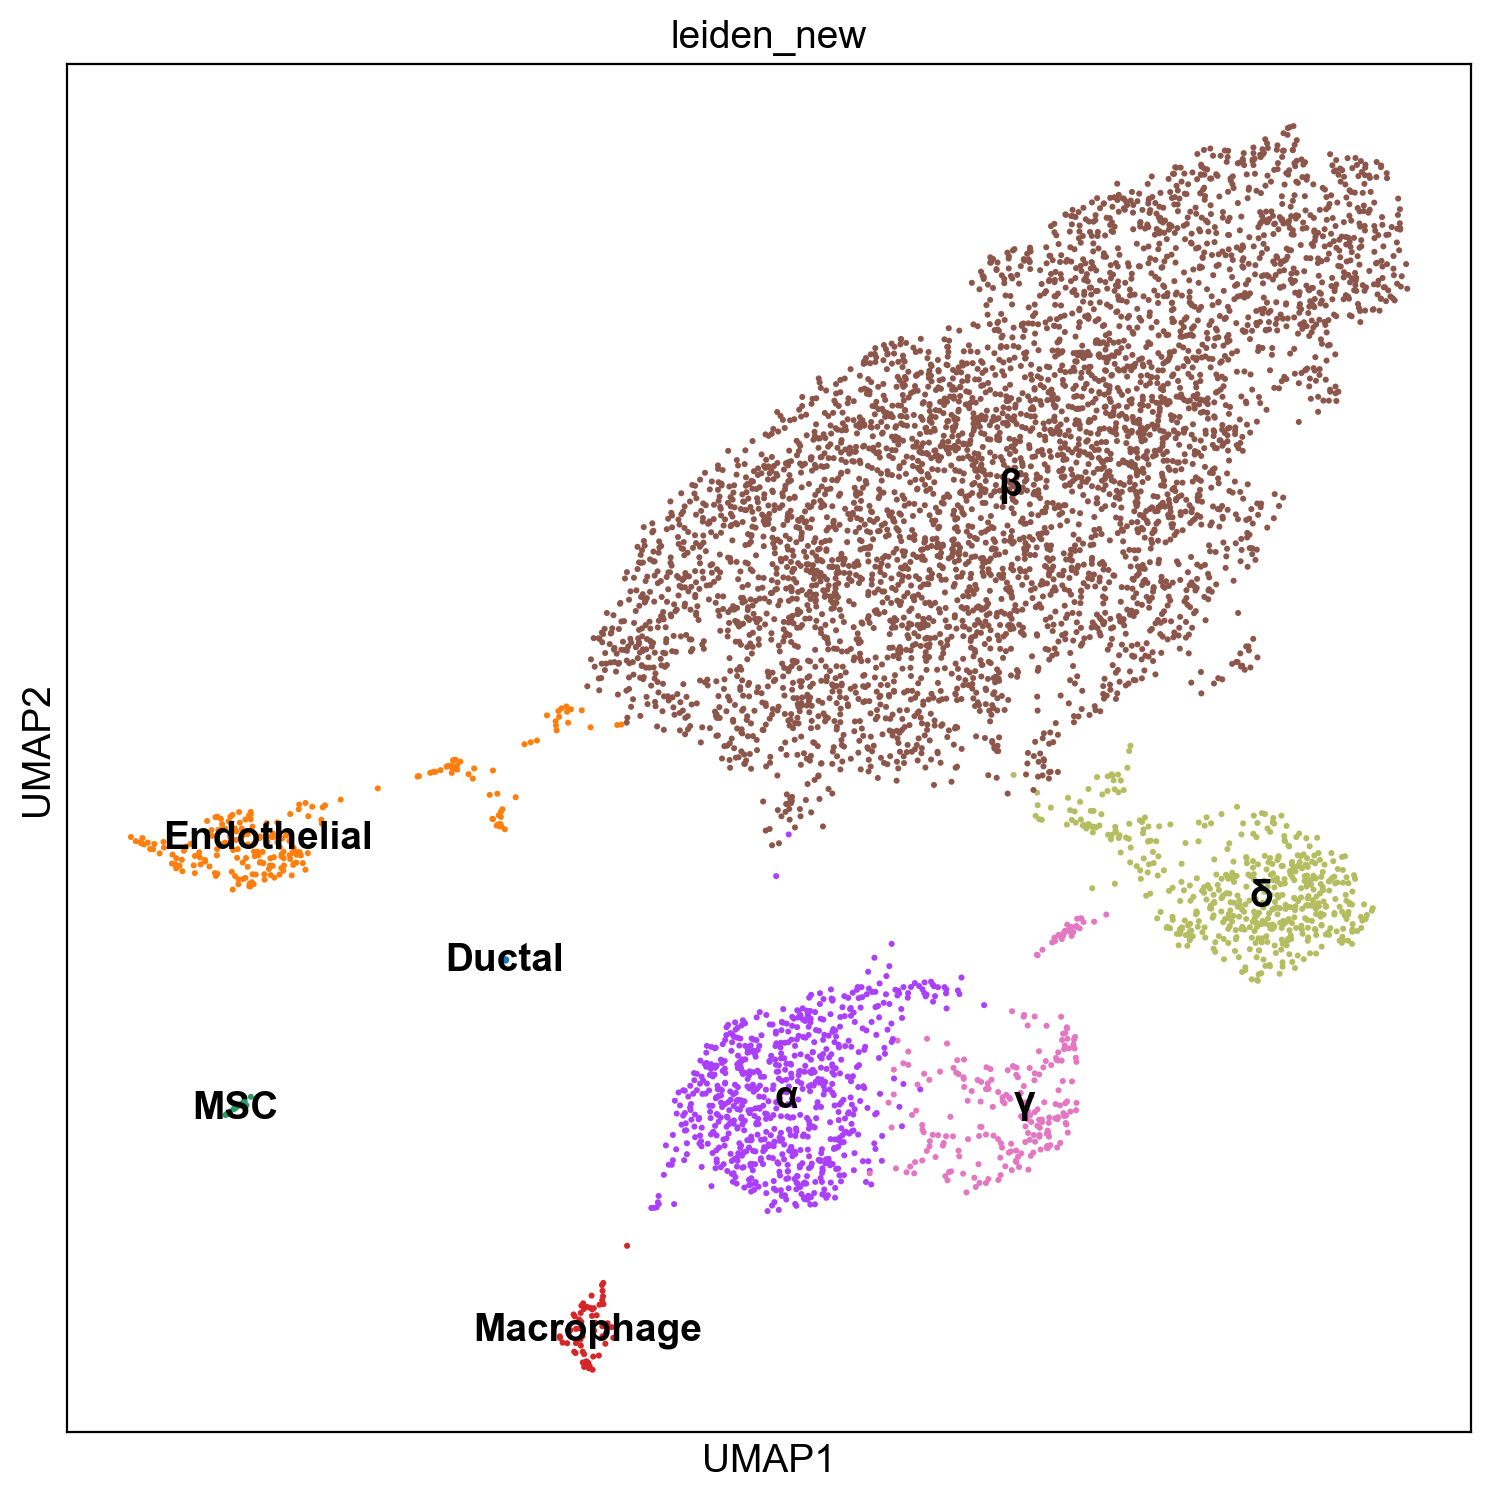

In [97]:
sc.pl.umap(adata, color='leiden_new', legend_loc = 'on data')

In [98]:
#orig_colors = adata.uns["leiden_new_colors"]
#print(orig_colors)

In [99]:
#random.seed(1122)
#new_colors = orig_colors
#random.shuffle(new_colors)
#print(new_colors)

#adata.uns["leiden_new_colors"] = ['#b5bd61', '#8c564b', '#aa40fc', '#ff7f0e', '#1f77b4', '#279e68', '#d62728', '#e377c2']

In [100]:
new_leiden_order = [
    "α",
    "β",
    "δ",
    "γ",
    "Endothelial",
    "Macrophage",
    "Ductal",
    "MSC"
]

adata.obs['leiden_new'] = adata.obs.leiden_new.cat.set_categories(new_leiden_order)

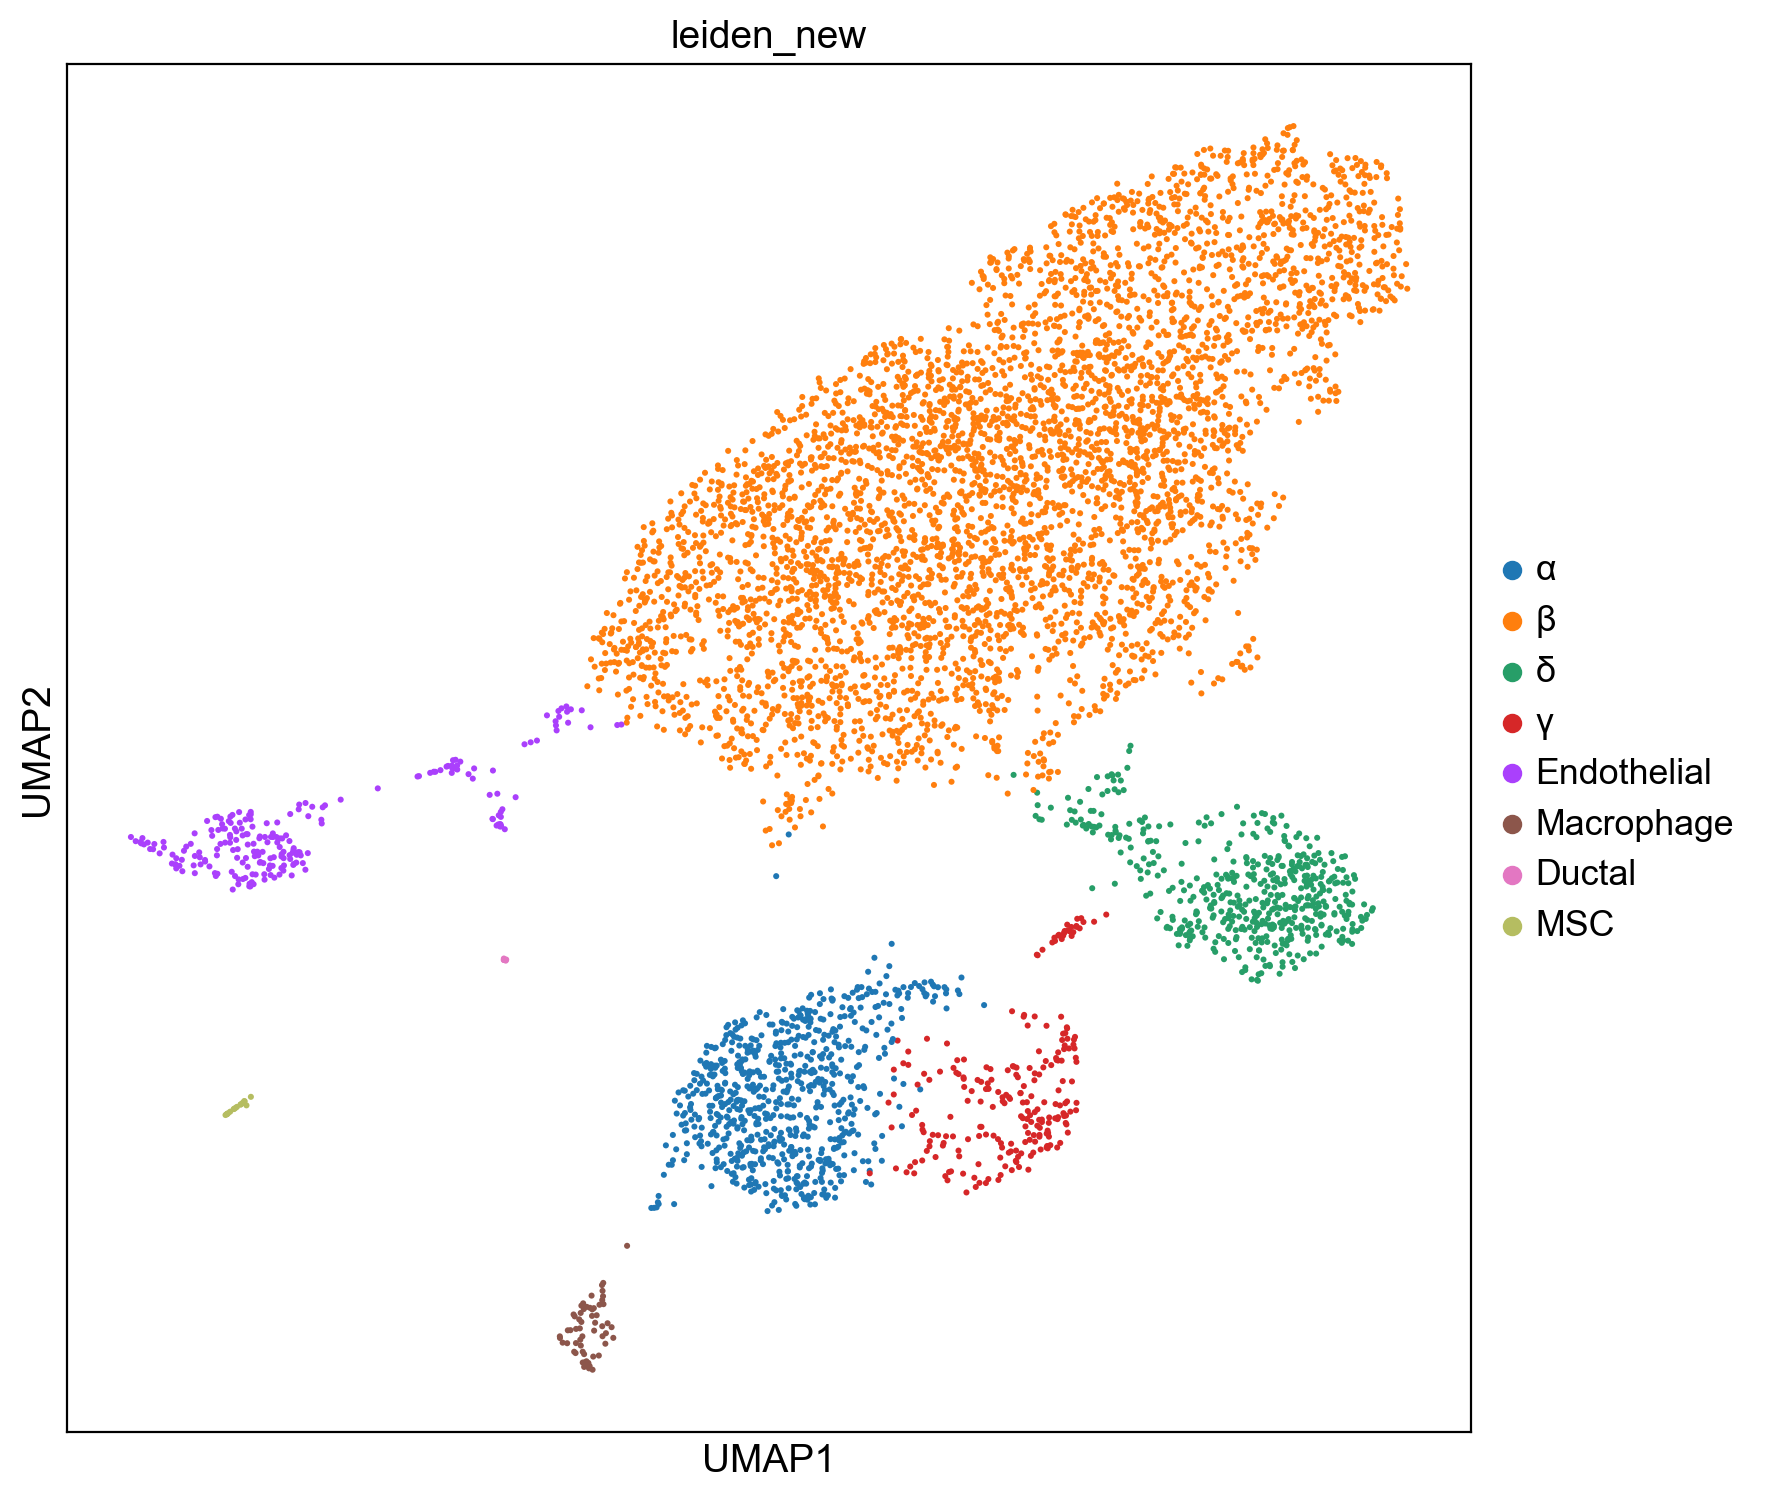

In [101]:
sc.pl.umap(adata, color='leiden_new')

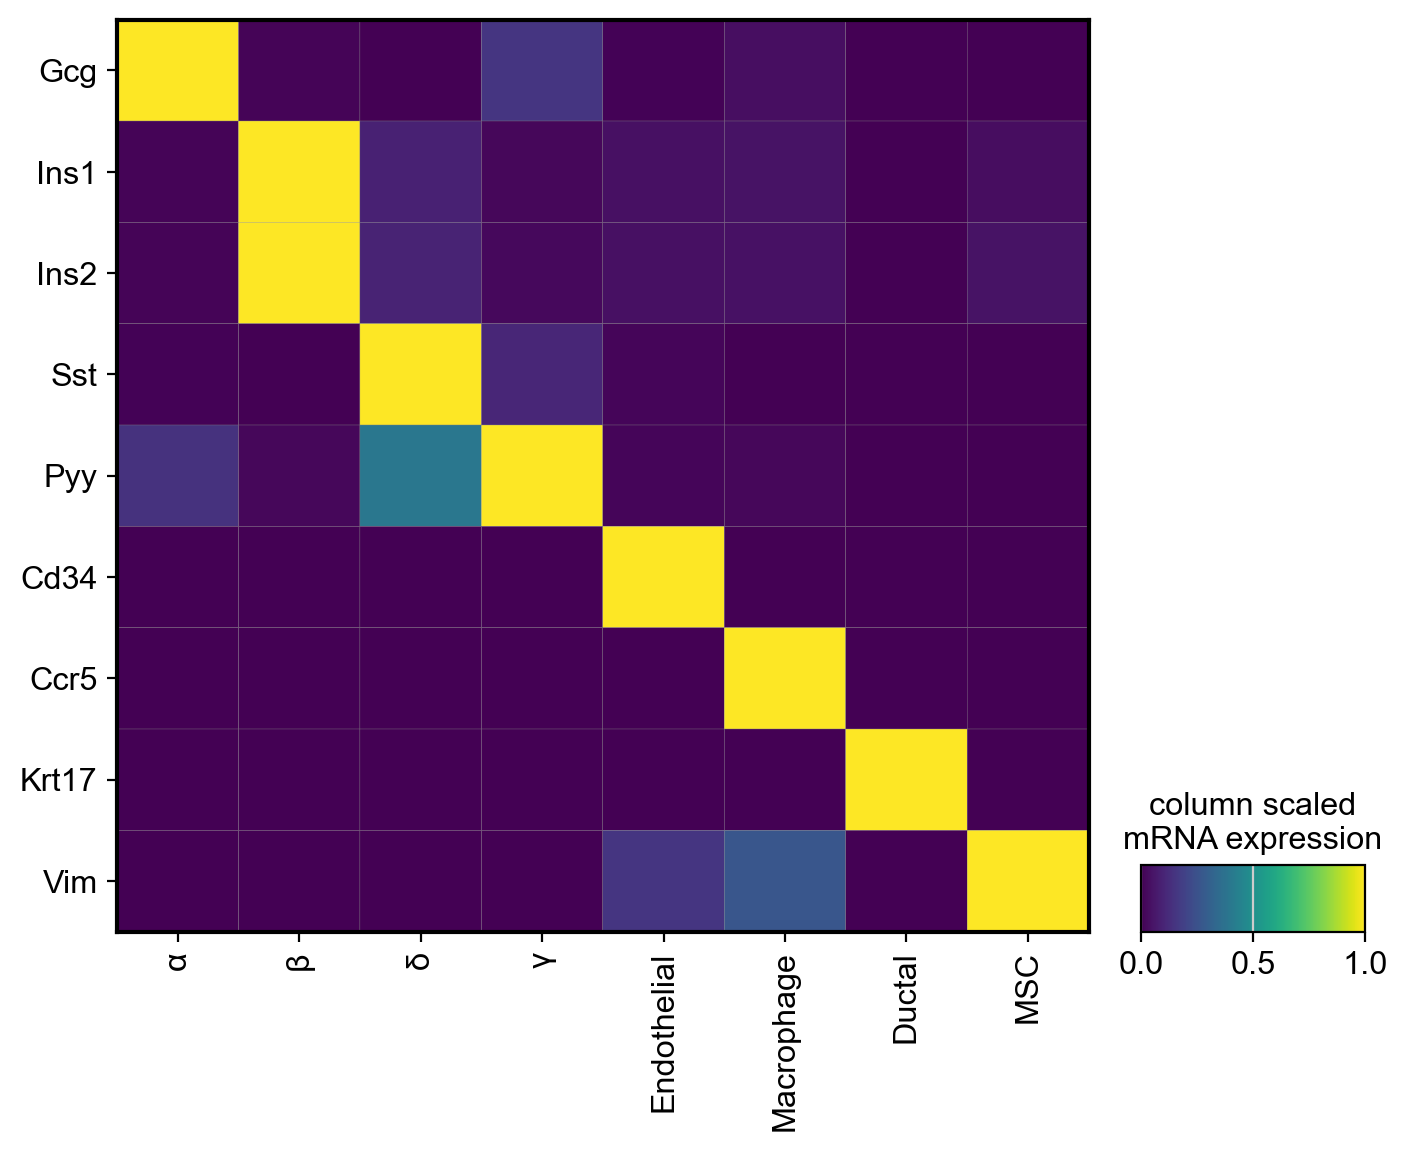

In [102]:
markers = [
    "Gcg",
    "Ins1",
    "Ins2",
    "Sst",
    "Pyy",
    "Cd34",
    "Ccr5",
    "Krt17",
    "Vim"
]

sc.pl.matrixplot(adata, markers, 'leiden_new', dendrogram=False, cmap='viridis',figsize=(8, 6),
                standard_scale='var', colorbar_title='column scaled\nmRNA expression', swap_axes=True)

D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:452: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:453: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:452: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:452: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:453: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:452:

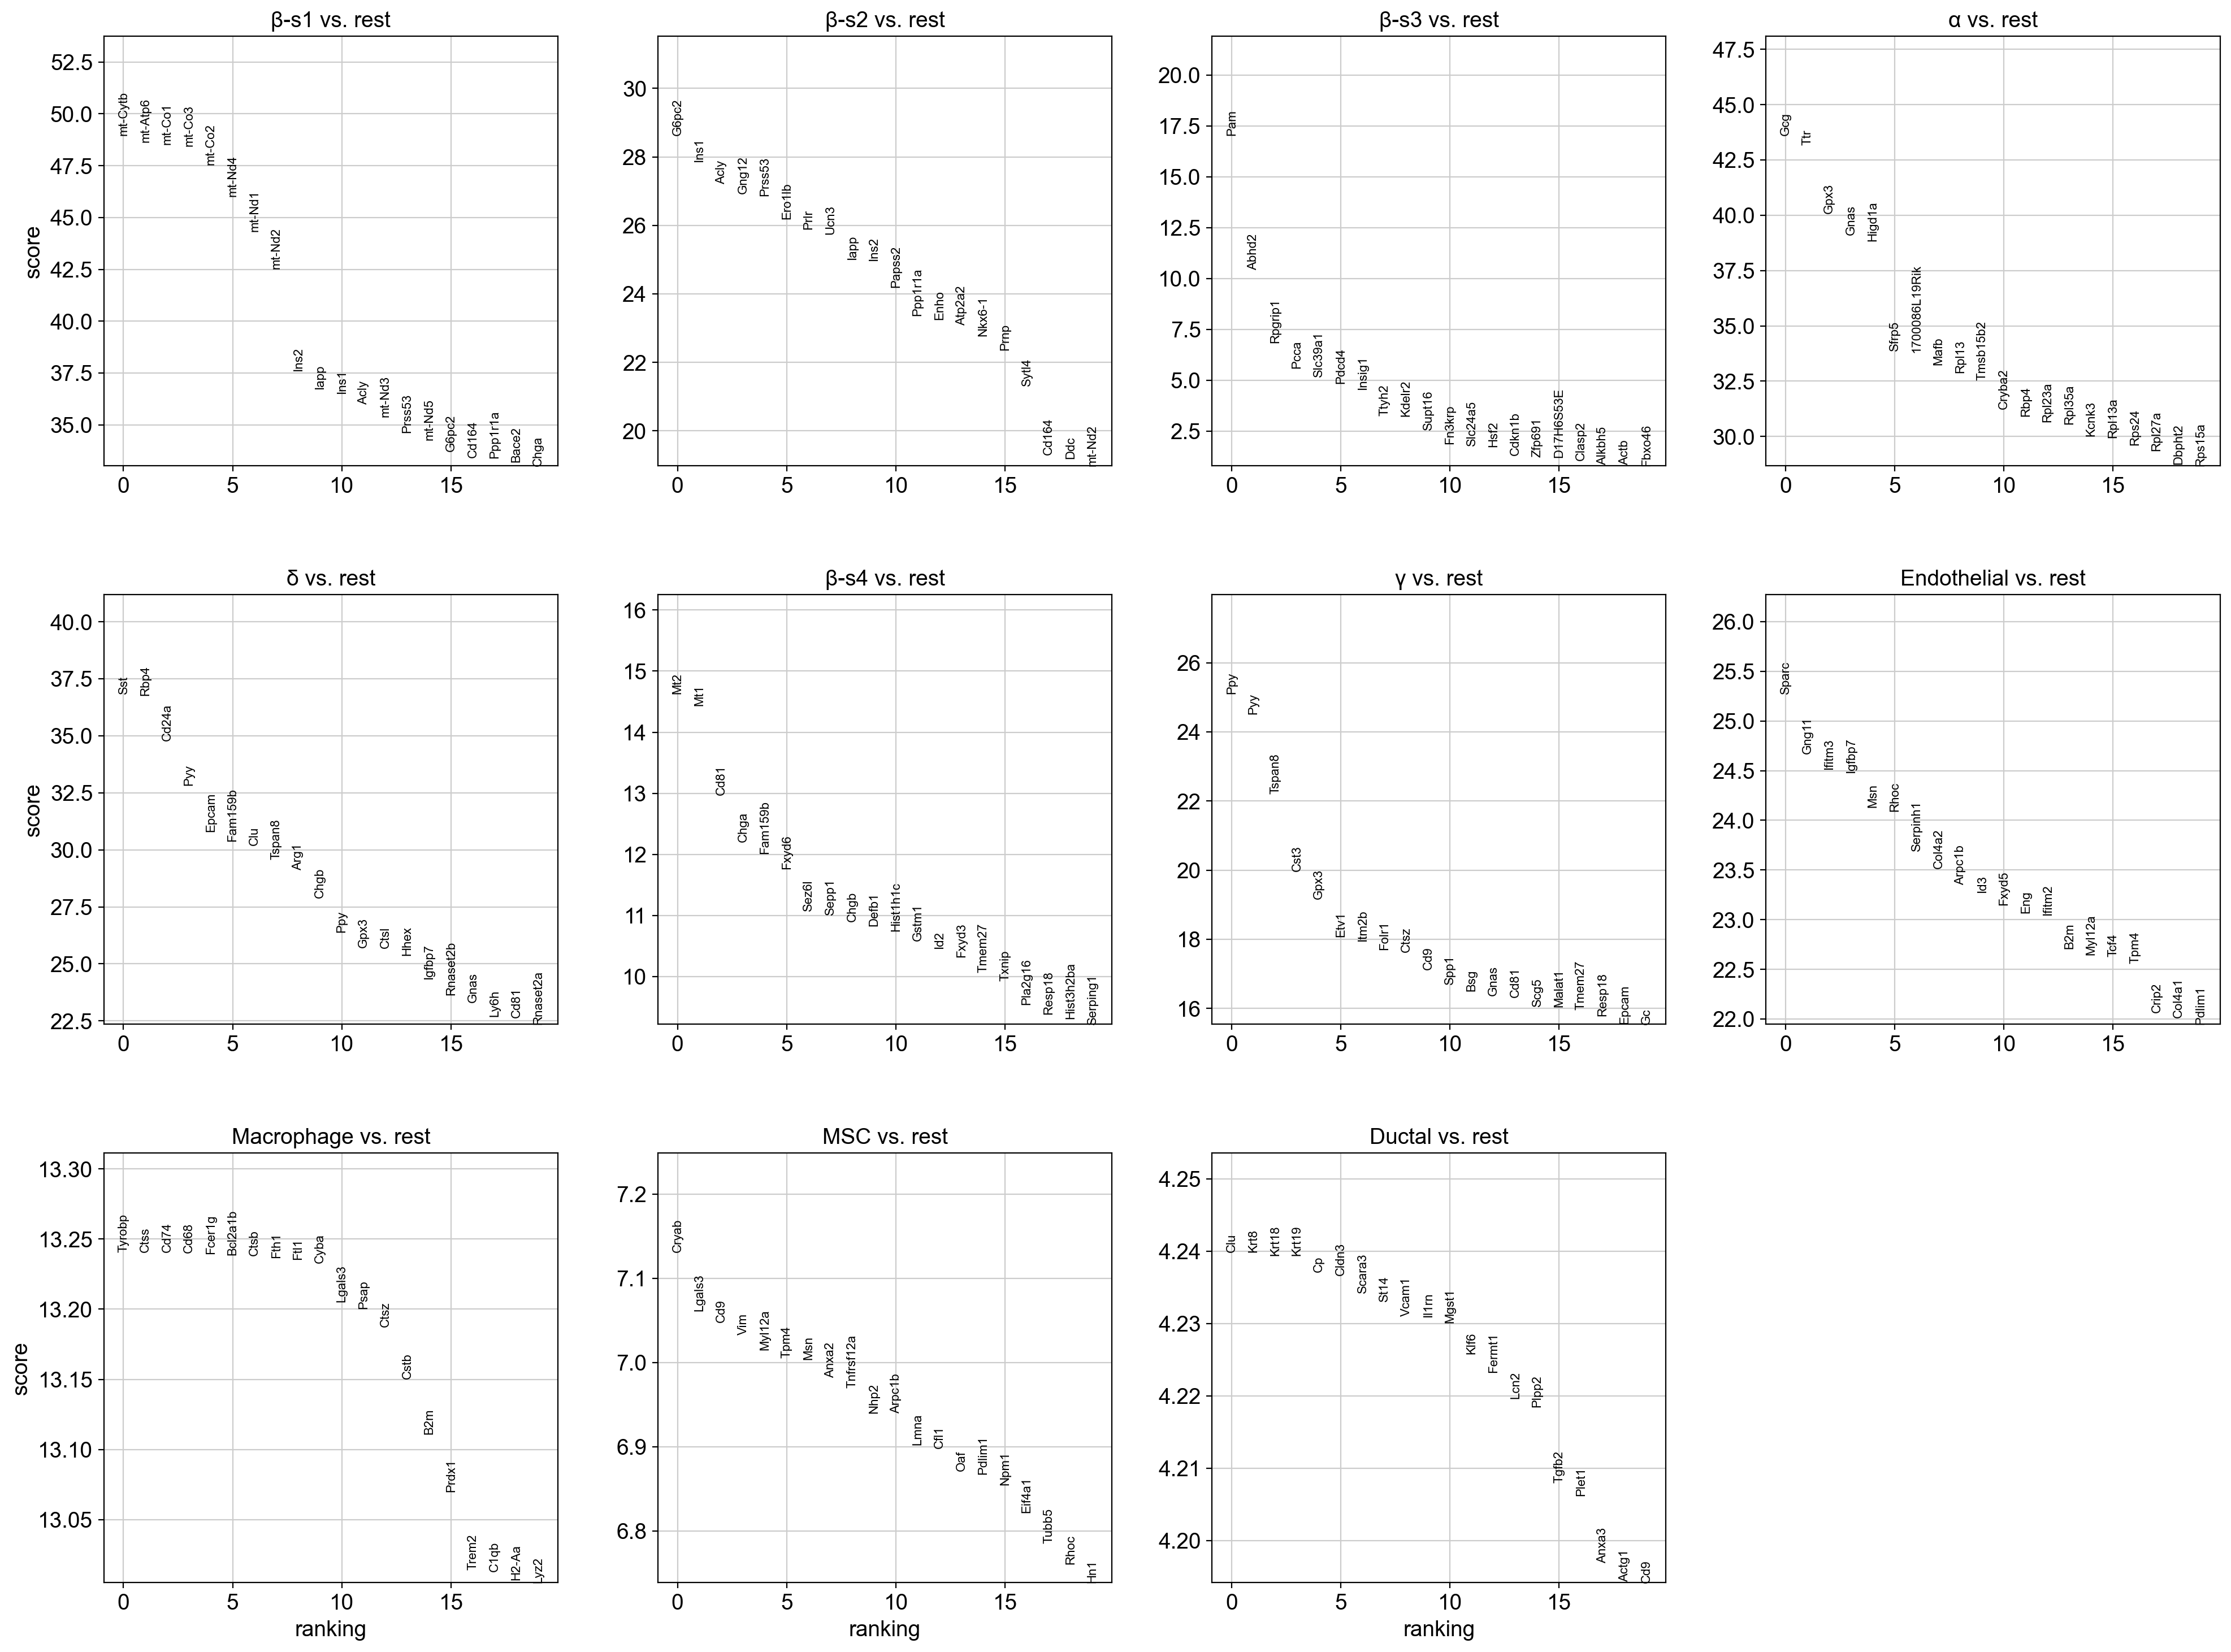

In [103]:
sc.tl.rank_genes_groups(adata, 'leiden', method = 'wilcoxon')
#diferential analysis, key paraments: groups, reference

sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(6, 6))

sc.pl.rank_genes_groups(adata, n_genes = 20, sharey = False)

# HCD mouse

In [104]:
adata_hfd = sc.read_10x_mtx(
    "E:/KCL/scRNAseq/scRNAseq/mouse/GSM6160615/", 
    var_names = 'gene_symbols',
    cache = True
)

In [105]:
np.random.seed(201)

In [106]:
adata_hfd.obs['pseudo_group'] = np.random.randint(4, 7, size=len(adata_hfd.obs))

In [107]:
sc.pp.filter_cells(adata_hfd, min_genes=200)
sc.pp.filter_genes(adata_hfd, min_cells=3)

In [108]:
adata_hfd.var['mt'] = adata_hfd.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(
    adata_hfd, 
    qc_vars=['mt'], 
    percent_top = None, 
    log1p = False,
    inplace = True
)

In [109]:
adata_hfd.raw = adata_hfd

In [110]:
#sc.pl.violin(
#    adata_hfd,
#    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
#    jitter = 0.4,
#    multi_panel = True
#)

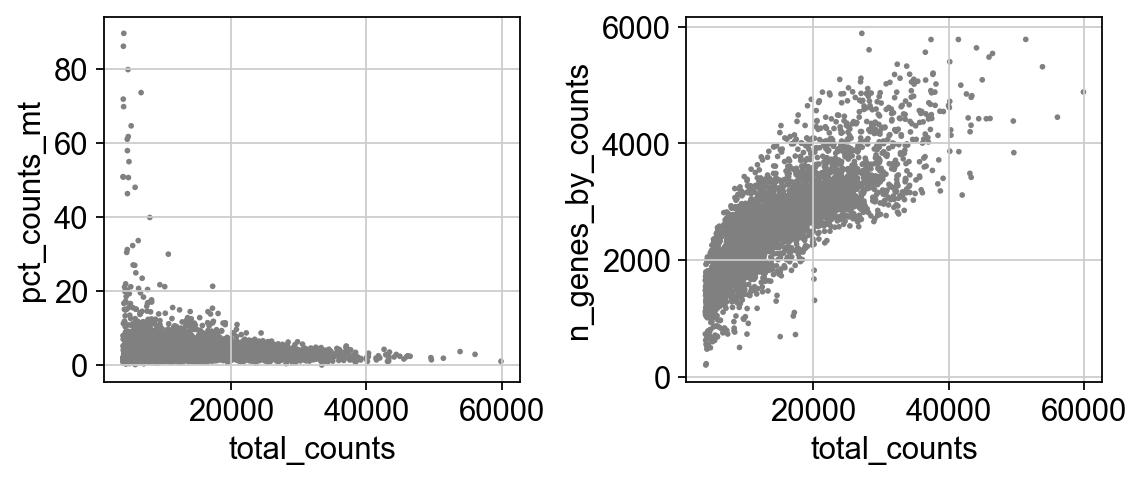

In [111]:
sc.settings.set_figure_params(dpi_save = 300)
fig, ax = plt.subplots(nrows = 1, ncols =2, figsize=(8, 3))

sc.pl.scatter(adata_hfd, x = 'total_counts', y = 'pct_counts_mt', ax = ax[0], show = False)
sc.pl.scatter(adata_hfd, x = 'total_counts', y = 'n_genes_by_counts', ax = ax[1], show = False)

plt.subplots_adjust(wspace=.4)

In [112]:
adata_hfd = adata_hfd[adata_hfd.obs.n_genes_by_counts < 4000, :]
adata_hfd = adata_hfd[adata_hfd.obs.pct_counts_mt < 10, :]

In [113]:
sc.pp.normalize_total(adata_hfd, target_sum = 1e4)
sc.pp.log1p(adata_hfd)

D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\preprocessing\_normalization.py:206: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


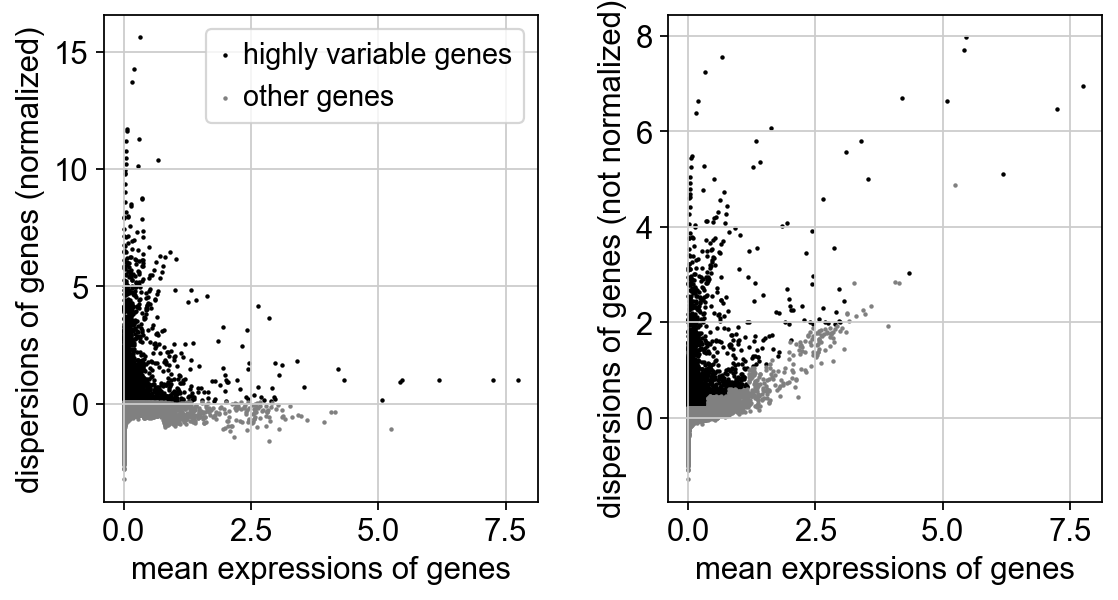

In [114]:
sc.pp.highly_variable_genes(adata_hfd, min_mean = 0.0125, max_mean=3, min_disp=0.5, n_top_genes = 4000)
sc.pl.highly_variable_genes(adata_hfd)

In [115]:
adata_hfd = adata_hfd[:, adata_hfd.var.highly_variable]

In [116]:
sc.pp.regress_out(adata_hfd, ['total_counts', 'pct_counts_mt'])
#不同细胞的total counts和线粒体基因比例可能不同，这种差异可能和测序深度有关，通过回归将这种差异去除掉

sc.pp.scale(adata_hfd, max_value=10)

D:\Anaconda3\envs\singlecell\Lib\site-packages\scanpy\preprocessing\_simple.py:641: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


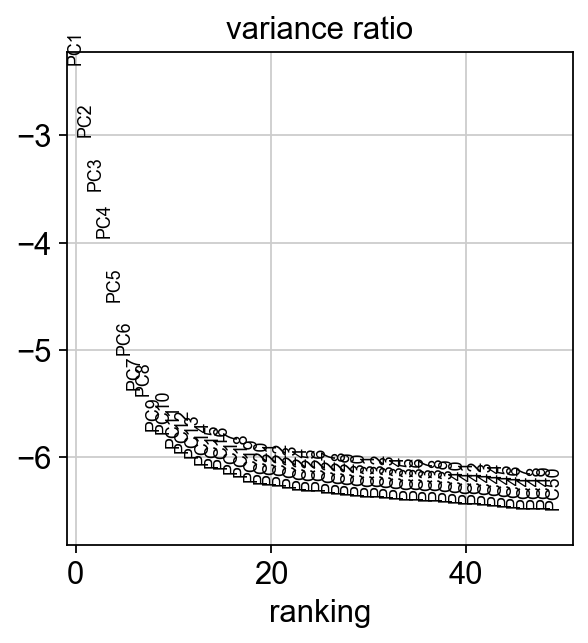

In [117]:
sc.tl.pca(adata_hfd, svd_solver = 'arpack')
sc.pl.pca_variance_ratio(adata_hfd, log=True, n_pcs = 50)

In [118]:
sc.pp.neighbors(adata_hfd, n_neighbors = 10, n_pcs = 30)
sc.tl.umap(adata_hfd)

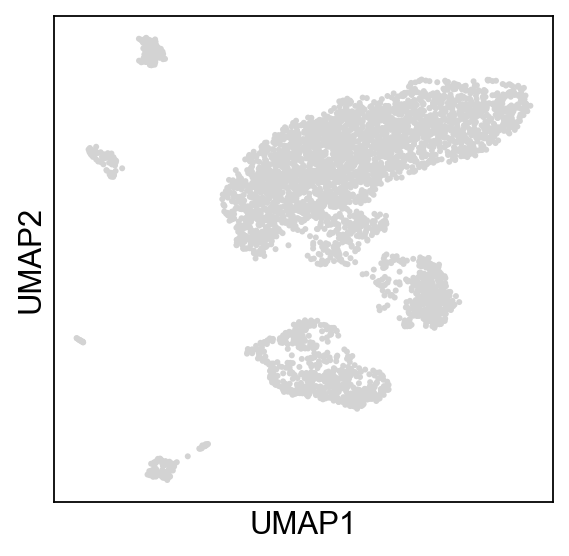

In [119]:
sc.pl.umap(adata_hfd)

## Merge NCD and HFD mouse islet scRNAseq data

In [120]:
var_names = adata_hfd.var_names.intersection(adata.var_names)
adata_hfd = adata_hfd[:, var_names]
adata = adata[:, var_names]

In [121]:
sc.tl.ingest(adata_hfd, adata, obs='leiden')

D:\Anaconda3\envs\singlecell\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
<frozen _collections_abc>:949: ImplicitModificationWarning: Setting element `.obsm['rep']` of view, initializing view as actual.
<frozen _collections_abc>:949: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
<frozen _collections_abc>:949: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.


In [122]:
adata_hfd.uns['leiden_colors'] = adata.uns['leiden_colors']

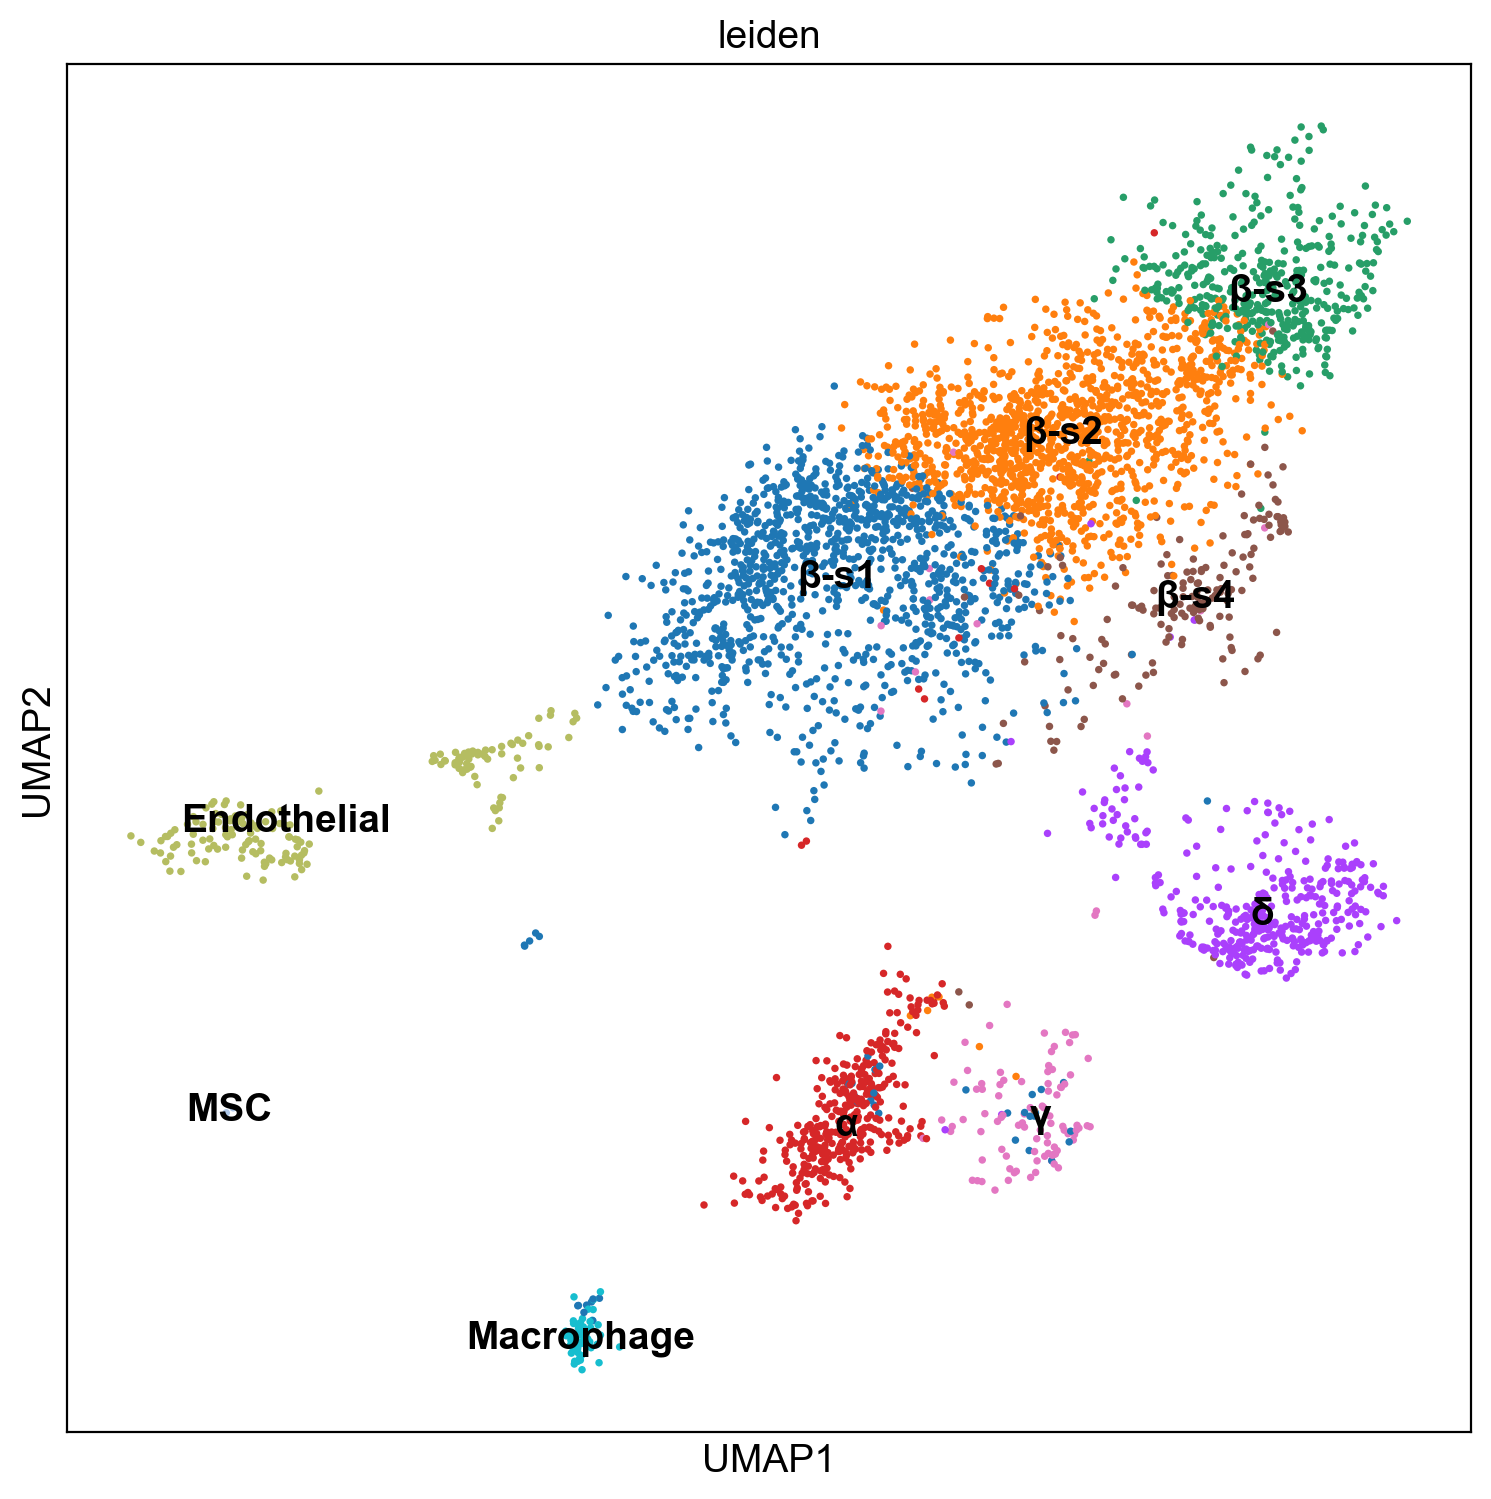

In [123]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(9, 9))
sc.pl.umap(adata_hfd, color=['leiden'],wspace=0.0001, legend_loc='on data')

In [124]:
adata_hfd

AnnData object with n_obs × n_vars = 4149 × 2836
    obs: 'pseudo_group', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden_colors'
    obsm: 'X_pca', 'X_umap', 'rep'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [125]:
adata_merged = adata_hfd.concatenate(adata, batch_categories=['HFD','CD'])
adata_merged.obs.leiden = adata_merged.obs.leiden.astype('category')
adata_merged.obs.leiden.cat.reorder_categories(adata.obs.leiden.cat.categories)
adata_merged.uns['leiden_colors'] = adata.uns['leiden_colors']

C:\Users\lyuze\AppData\Local\Temp\ipykernel_31212\897403458.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = adata_hfd.concatenate(adata, batch_categories=['HFD','CD'])


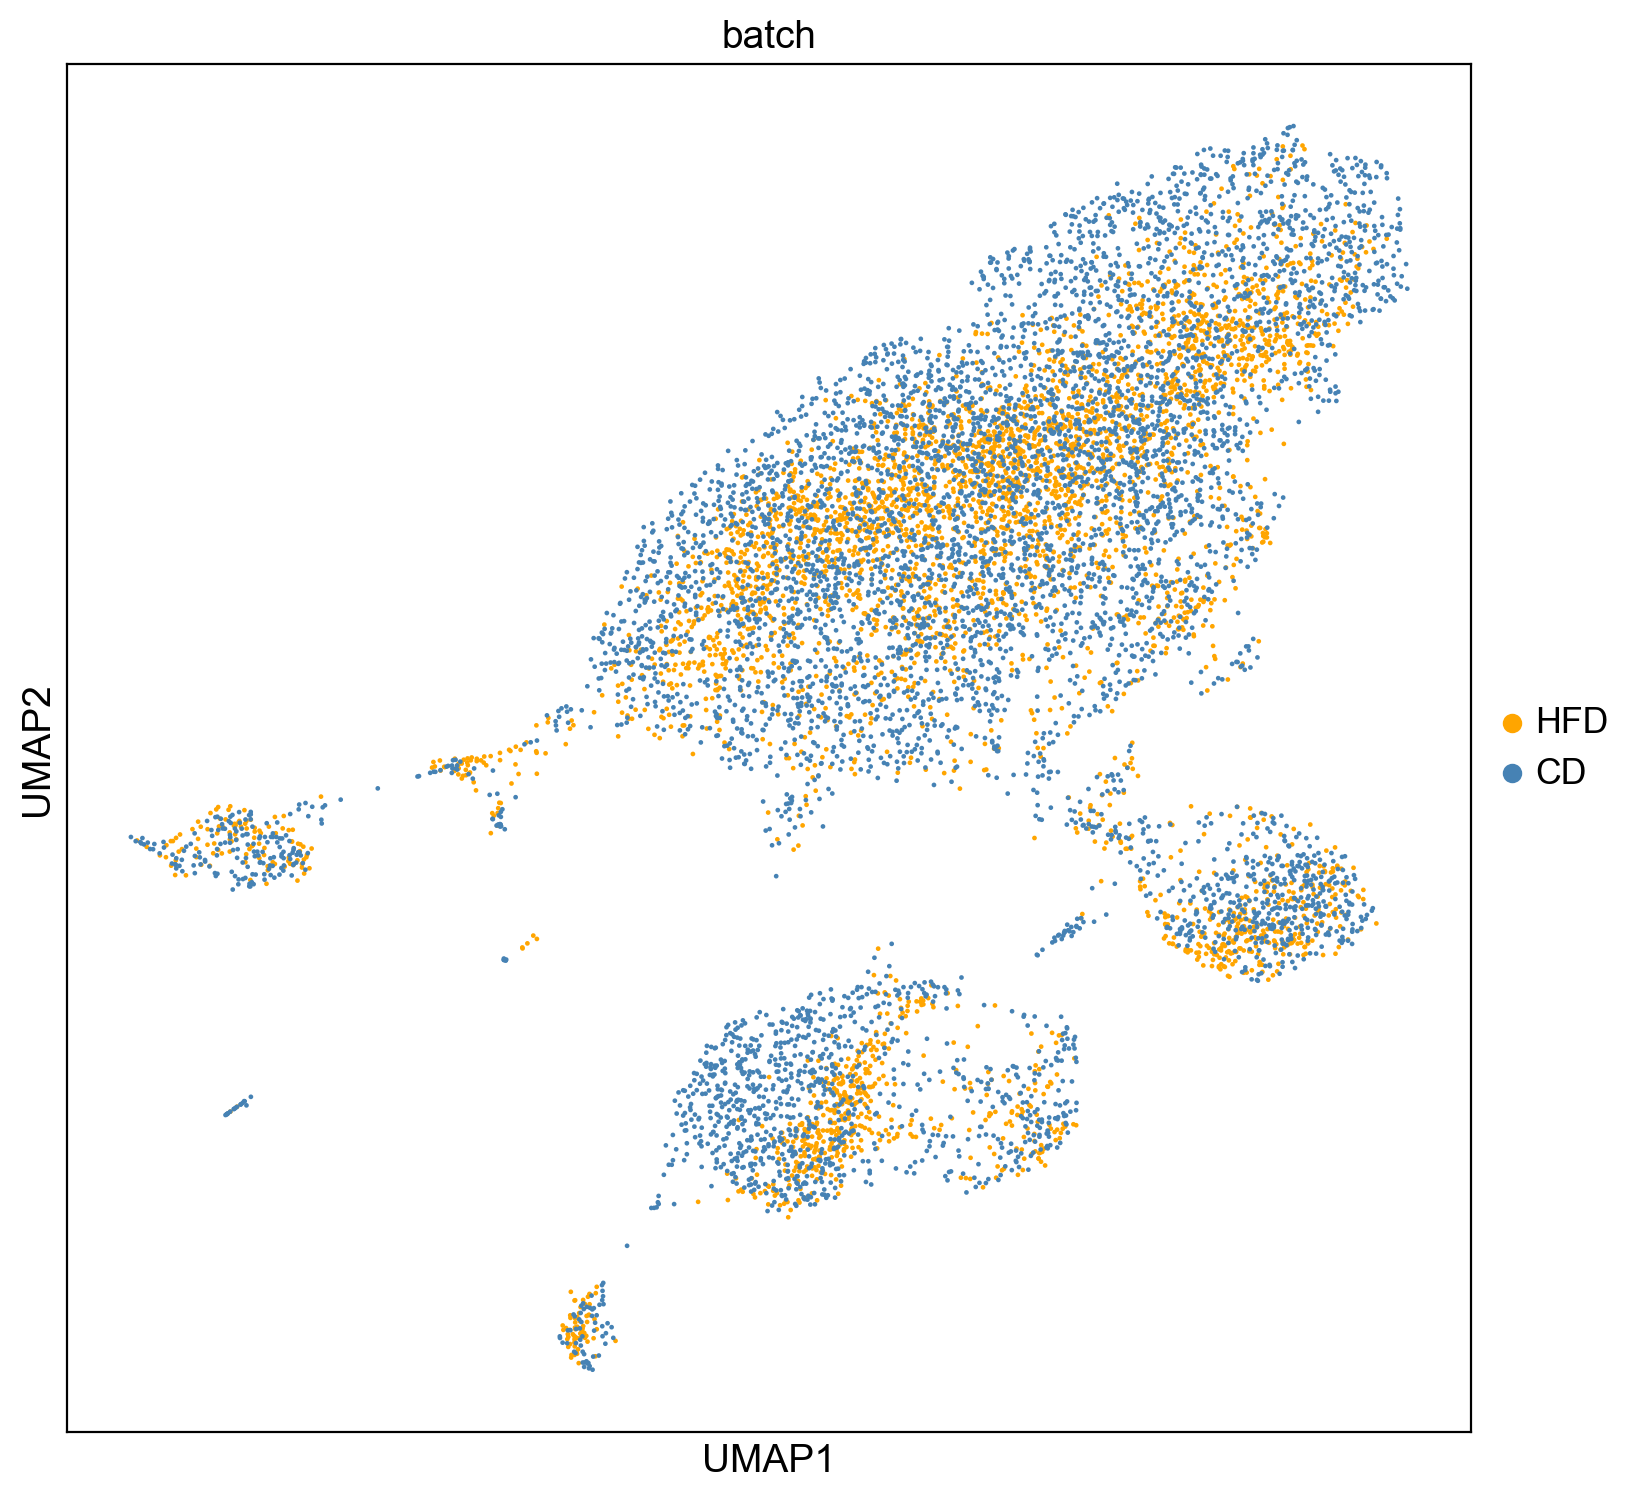

In [126]:
custom_palette = {
    'HFD': 'orange',
    'CD': 'steelblue',
}

sc.pl.umap(adata_merged, color = 'batch', palette=custom_palette)

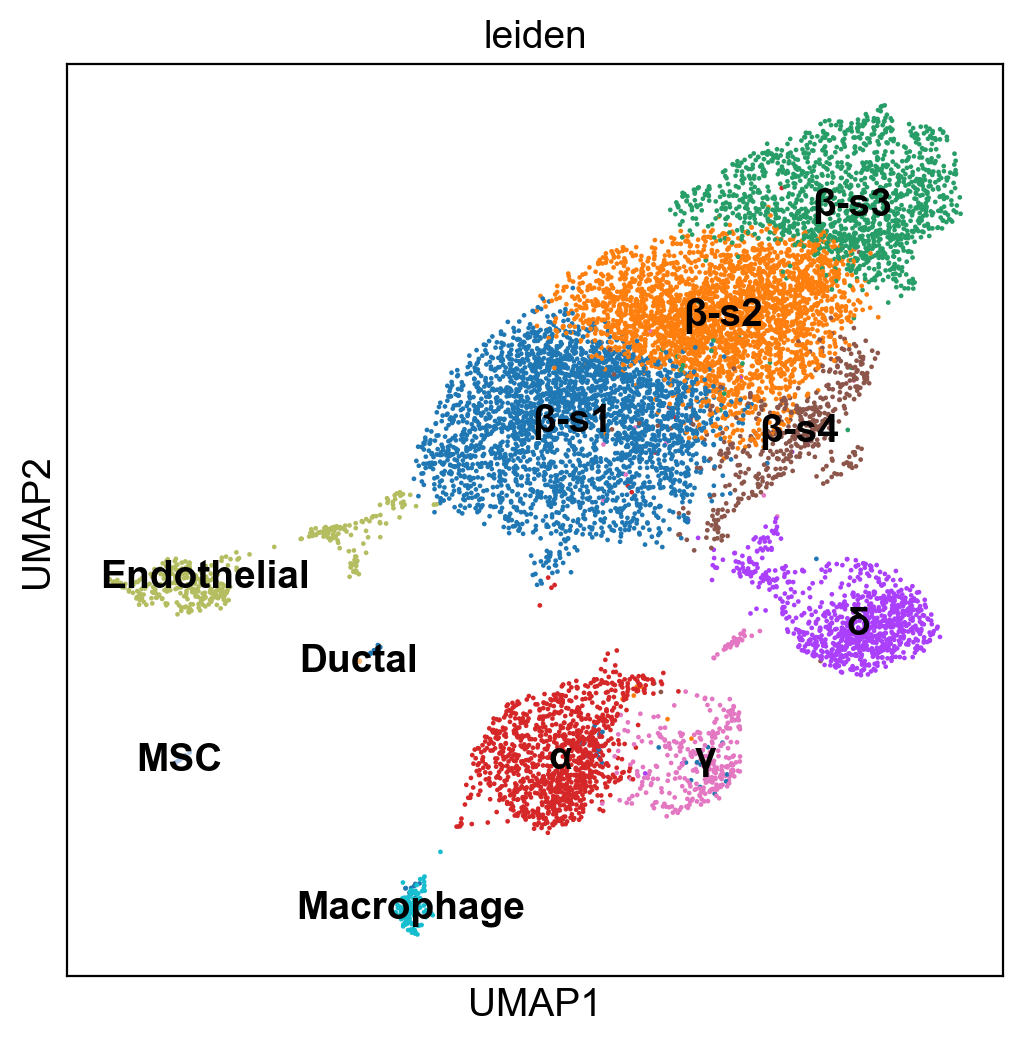

In [127]:
sc.settings.set_figure_params(dpi = 100, dpi_save=300, figsize=(6,6))
sc.pl.umap(adata_merged, color = 'leiden', legend_loc='on data')

In [128]:
print(adata_merged.raw.X)

  (0, 2)	1.0
  (0, 6)	1.0
  (0, 9)	1.0
  (0, 16)	1.0
  (0, 24)	1.0
  (0, 25)	2.0
  (0, 34)	1.0
  (0, 41)	1.0
  (0, 44)	1.0
  (0, 45)	1.0
  (0, 71)	1.0
  (0, 101)	1.0
  (0, 103)	1.0
  (0, 120)	1.0
  (0, 123)	5.0
  (0, 126)	1.0
  (0, 130)	1.0
  (0, 133)	1.0
  (0, 164)	1.0
  (0, 170)	1.0
  (0, 173)	1.0
  (0, 189)	1.0
  (0, 190)	1.0
  (0, 191)	2.0
  (0, 205)	1.0
  :	:
  (10439, 15969)	16.0
  (10439, 15972)	1.0
  (10439, 15973)	1.0
  (10439, 15984)	5408.0
  (10439, 15988)	1.0
  (10439, 15996)	2.0
  (10439, 15997)	3.0
  (10439, 15998)	2.0
  (10439, 16001)	2.0
  (10439, 16023)	1.0
  (10439, 16024)	4.0
  (10439, 16027)	1.0
  (10439, 16030)	3.0
  (10439, 16033)	1.0
  (10439, 16038)	53.0
  (10439, 16039)	15.0
  (10439, 16040)	63.0
  (10439, 16041)	45.0
  (10439, 16043)	99.0
  (10439, 16044)	111.0
  (10439, 16045)	2.0
  (10439, 16047)	23.0
  (10439, 16048)	3.0
  (10439, 16050)	60.0
  (10439, 16055)	1.0


In [130]:
# adata_merged.write('hfd_mouse_islet_scRNAseq_raw_counts.h5ad')

## Pseudobulk

In [141]:
adata_merged

AnnData object with n_obs × n_vars = 10440 × 2836
    obs: 'pseudo_group', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_new', 'batch'
    var: 'gene_ids', 'mt', 'highly_variable', 'n_cells-CD', 'n_cells_by_counts-CD', 'mean_counts-CD', 'pct_dropout_by_counts-CD', 'total_counts-CD', 'means-CD', 'dispersions-CD', 'dispersions_norm-CD', 'mean-CD', 'std-CD', 'n_cells-HFD', 'n_cells_by_counts-HFD', 'mean_counts-HFD', 'pct_dropout_by_counts-HFD', 'total_counts-HFD', 'means-HFD', 'dispersions-HFD', 'dispersions_norm-HFD', 'mean-HFD', 'std-HFD'
    uns: 'leiden_colors', 'batch_colors'
    obsm: 'X_pca', 'X_umap'

In [142]:
pseudobulk_data = {}

In [143]:
cell_types = list(adata_merged.obs['leiden'].unique())

In [144]:
#Sample_no = list(adata_merged.obs['pseudo_group'].unique())
sample_no = [1, 2, 3, 4, 5, 6]

In [145]:
cell_types

['β-s3',
 'β-s2',
 'β-s1',
 'α',
 'δ',
 'Endothelial',
 'γ',
 'β-s4',
 'Macrophage',
 'MSC',
 'Ductal']

In [146]:
for s in sample_no:
    adata_sample = adata_merged[adata_merged.obs['pseudo_group'] == s]

    for c in cell_types:
        adata_sample_cell = adata_sample[adata_sample.obs['leiden'] == c]
        column_name = str(str(s) + '_' + c)
        pseudobulk_data[column_name] = adata_sample_cell.raw.X.sum(axis=0).tolist()[0]

In [147]:
list(adata_merged.raw.var.index)

['Xkr4',
 'Sox17',
 'Mrpl15',
 'Lypla1',
 'Tcea1',
 'Rgs20',
 'Atp6v1h',
 'Rb1cc1',
 '4732440D04Rik',
 'St18',
 'Pcmtd1',
 'Gm26901',
 'Sntg1',
 'Rrs1',
 'Adhfe1',
 'Mybl1',
 'Vcpip1',
 '1700034P13Rik',
 'Sgk3',
 'Mcmdc2',
 'Snhg6',
 'Tcf24',
 'Ppp1r42',
 'Cops5',
 'Cspp1',
 'Arfgef1',
 'Cpa6',
 'Prex2',
 'A830018L16Rik',
 'Sulf1',
 'Slco5a1',
 'Prdm14',
 'Ncoa2',
 'Gm29570',
 'Tram1',
 'Lactb2',
 'Eya1',
 'Trpa1',
 'Kcnb2',
 'Terf1',
 '4930444P10Rik',
 'Rpl7',
 'Rdh10',
 'Stau2',
 'Ube2w',
 'Tceb1',
 'D030040B21Rik',
 'Tmem70',
 'Ly96',
 'Jph1',
 'Gdap1',
 'Gm28784',
 'Pi15',
 'Crispld1',
 'Pkhd1',
 'Mcm3',
 '6720483E21Rik',
 'Paqr8',
 'Efhc1',
 'Tram2',
 'Tmem14a',
 'Gsta3',
 'Gm29107',
 'Ogfrl1',
 'B3gat2',
 'Smap1',
 'Sdhaf4',
 'Fam135a',
 'Lmbrd1',
 'Adgrb3',
 'Phf3',
 'Ptp4a1',
 'Khdrbs2',
 'Prim2',
 'Rab23',
 'Bag2',
 'Zfp451',
 'Dst',
 'Gm37233',
 'Ccdc115',
 'Imp4',
 'Ptpn18',
 '4930568A12Rik',
 'Amer3',
 'Arhgef4',
 'Gm38336',
 'Fam168b',
 'Plekhb2',
 'Hs6st1',
 'Uggt1',
 'Ne

In [148]:
pseudobulk_df = pd.DataFrame(pseudobulk_data, index=list(adata_merged.raw.var.index))

In [149]:
pseudobulk_df

,1_β-s3,1_β-s2,1_β-s1,1_α,1_δ,1_Endothelial,1_γ,1_β-s4,1_Macrophage,1_MSC,...,6_β-s2,6_β-s1,6_α,6_δ,6_Endothelial,6_γ,6_β-s4,6_Macrophage,6_MSC,6_Ductal
Xkr4,3.0,1.0,6.0,4.0,1.0,0.0,0.0,3.0,0.0,0.0,...,9.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
Sox17,0.0,0.0,1.0,0.0,0.0,101.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,43.0,0.0,0.0,0.0,0.0,0.0
Mrpl15,44.0,124.0,175.0,69.0,57.0,70.0,28.0,20.0,15.0,6.0,...,92.0,101.0,54.0,52.0,38.0,14.0,12.0,7.0,0.0,0.0
Lypla1,54.0,173.0,182.0,45.0,39.0,26.0,13.0,20.0,8.0,1.0,...,154.0,166.0,28.0,23.0,31.0,8.0,13.0,5.0,0.0,0.0
Tcea1,79.0,244.0,305.0,80.0,66.0,47.0,34.0,33.0,10.0,3.0,...,221.0,212.0,70.0,64.0,50.0,13.0,28.0,8.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tmlhe,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
AC168977.1,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PISD,128.0,391.0,390.0,157.0,151.0,19.0,43.0,69.0,15.0,2.0,...,458.0,490.0,131.0,132.0,18.0,42.0,71.0,10.0,0.0,0.0
DHRSX,47.0,140.0,189.0,26.0,31.0,40.0,17.0,23.0,7.0,0.0,...,68.0,92.0,23.0,24.0,35.0,6.0,16.0,9.0,0.0,0.0


In [150]:
# pseudobulk_df.to_excel('hfd_mouse_islet_raw_counts.xlsx')

In [164]:
adata_delta_cell = adata_merged[adata_merged.obs['leiden'] == 'δ']

In [165]:
adata_delta_cell

View of AnnData object with n_obs × n_vars = 880 × 2836
    obs: 'pseudo_group', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_new', 'batch'
    var: 'gene_ids', 'mt', 'highly_variable', 'n_cells-CD', 'n_cells_by_counts-CD', 'mean_counts-CD', 'pct_dropout_by_counts-CD', 'total_counts-CD', 'means-CD', 'dispersions-CD', 'dispersions_norm-CD', 'mean-CD', 'std-CD', 'n_cells-HFD', 'n_cells_by_counts-HFD', 'mean_counts-HFD', 'pct_dropout_by_counts-HFD', 'total_counts-HFD', 'means-HFD', 'dispersions-HFD', 'dispersions_norm-HFD', 'mean-HFD', 'std-HFD'
    uns: 'leiden_colors', 'batch_colors'
    obsm: 'X_pca', 'X_umap'

In [174]:
adata_delta_cell[adata_delta_cell.obs['pseudo_group'] == 6]

View of AnnData object with n_obs × n_vars = 121 × 2836
    obs: 'pseudo_group', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_new', 'batch'
    var: 'gene_ids', 'mt', 'highly_variable', 'n_cells-CD', 'n_cells_by_counts-CD', 'mean_counts-CD', 'pct_dropout_by_counts-CD', 'total_counts-CD', 'means-CD', 'dispersions-CD', 'dispersions_norm-CD', 'mean-CD', 'std-CD', 'n_cells-HFD', 'n_cells_by_counts-HFD', 'mean_counts-HFD', 'pct_dropout_by_counts-HFD', 'total_counts-HFD', 'means-HFD', 'dispersions-HFD', 'dispersions_norm-HFD', 'mean-HFD', 'std-HFD'
    uns: 'leiden_colors', 'batch_colors'
    obsm: 'X_pca', 'X_umap'